# Mini-LLM Alusta Alkaen: "Lumi"-kieli ja PyTorch

Tässä Jupyter Notebookissa rakennamme **täysin toimivan Decoder-only Transformer -kielimallin (LLM)** alusta alkaen ilman PyTorchin valmiita korkean tason Transformer-moduuleita. Kirjoitamme itse jokaisen matemaattisen osan, jotta näemme tarkalleen, miten ne toimivat.

### Mitä rakennamme?
1. **Keksitty lelukieli ("Lumi")**: Kieli, jossa on hyvin pieni sanasto (14 sanaa) ja tiukat kieliopilliset säännöt. Tämä varmistaa, että voimme kouluttaa mallin sekunneissa tavallisella tietokoneella ja nähdä sen oppivan kieliopin.
2. **Oma Tokenizer**: Sanapohjainen kooderi, joka muuttaa sanat indekseiksi ja takaisin.
3. **Täydellinen Transformer-putki**:
   - **Embedding & Positional Embedding**: Sanojen muuttaminen vektoreiksi ja paikkatietojen lisääminen.
   - **RMSNorm (Root Mean Square Normalization)**: Moderni normalisointikerros (käytössä mm. Llama 3:ssa ja Gemmassa).
   - **Causal Multi-Head Attention (2 päätä)**: Laskee $Query$, $Key$ ja $Value$ projektiot, soveltaa kausaalisen maskin (estää mallia näkemästä tulevaisuuteen) ja laskee Softmax-huomiopainot.
   - **Feed-Forward Network (FFN)**: Lineaariset kerrokset ja GELU-aktivaatio.
   - **TransformerBlock & MiniLLM**: Yhdistetään kaikki residual-yhteyksillä.
4. **Koulutuspalikka (Training Loop)**: Koulutamme mallia luomallamme aineistolla ja piirrämme häviökäyrän.
5. **Interaktiivinen Prompter**: Generointifunktio, joka tulostaa ennustuksen aikana sanojen todennäköisyydet.
6. **Huomiokartan (Attention Map) visualisointi**: Piirrämme heatmapin, joka näyttää, mihin sanoihin kukin attention-pää kiinnittää huomiota.

Aloitetaan tuomalla tarvittavat kirjastot.


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

# Asetetaan satunnaisuusgeneraattorien siemenet toistettavuutta varten
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Käytetään laitetta: {device}")


Käytetään laitetta: mps


## Vaihe 1: Keksitty lelukieli ("Lumi") ja Tokenizer

Suunnitellaan yksinkertainen kieli, joka kuvaa eläinten tarinoita. Sanastossa on vain **14 sanaa**:
- **Erikoissanat**: `<pad>` (täyte), `<bos>` (lauseen alku), `<eos>` (lauseen loppu)
- **Subjektit/Objektit**: `kissa`, `koira`, `hiiri`, `kala`, `juusto`
- **Verbit**: `katsoo`, `jahtaa`, `syö`, `nukkuu`
- **Adverbit & Konjunktiot**: `ja`, `hyvin`

### Kielioppisäännöt:
Jotta malli voi oppia jotain merkityksellistä, lauseet noudattavat tiettyjä rakenteita:
1. Lause alkaa aina `<bos>` ja päättyy `<eos>`.
2. Rakenne 1: `[Subjekti] [Verbi] [Objekti] ja [Subjekti] [Verbi] hyvin` (esim. `kissa syö kala ja kissa nukkuu hyvin`)
3. Rakenne 2: `[Subjekti] [Verbi] [Objekti] ja [Subjekti] [Verbi] [Objekti]` (esim. `koira jahtaa kissa ja kissa katsoo hiiri`)
4. Kieliopilliset rajoitukset: `syö` liittyy vain sanoihin `kala` tai `juusto`. `nukkuu` voi esiintyä vain sanan `hyvin` kanssa.

Rakennetaan nyt tokenizer, joka muuttaa sanat kokonaisluvuiksi (ID:iksi) ja takaisin.


In [13]:
class LumiTokenizer:
    def __init__(self):
        # Sanasto (Vocabulary)
        self.vocab = [
            '<pad>', '<bos>', '<eos>',
            'kissa', 'koira', 'hiiri', 'kala', 'juusto',
            'katsoo', 'jahtaa', 'syö', 'nukkuu',
            'ja', 'hyvin'
        ]
        self.word2id = {word: idx for idx, word in enumerate(self.vocab)}
        self.id2word = {idx: word for idx, word in enumerate(self.vocab)}
        self.pad_token_id = self.word2id['<pad>']
        self.bos_token_id = self.word2id['<bos>']
        self.eos_token_id = self.word2id['<eos>']
        
    @property
    def vocab_size(self):
        return len(self.vocab)
        
    def encode(self, text):
        """Muuttaa tekstimerkkijonon lista-muotoiseksi ID-sarjaksi."""
        words = text.strip().split()
        return [self.word2id[w] for w in words if w in self.word2id]
        
    def decode(self, ids):
        """Muuttaa ID-sarjan takaisin tekstiksi."""
        words = []
        for idx in ids:
            if isinstance(idx, torch.Tensor):
                idx = idx.item()
            words.append(self.id2word[idx])
        return " ".join(words)

# Alustetaan tokenizer ja testataan
tokenizer = LumiTokenizer()
testi_lause = "<bos> kissa jahtaa hiiri ja kissa nukkuu hyvin <eos>"
koodattu = tokenizer.encode(testi_lause)
dekoodattu = tokenizer.decode(koodattu)

print(f"Alkuperäinen: {testi_lause}")
print(f"Koodattu:     {koodattu}")
print(f"Dekoodattu:   {dekoodattu}")
print(f"Sanaston koko: {tokenizer.vocab_size} sanaa.")


Alkuperäinen: <bos> kissa jahtaa hiiri ja kissa nukkuu hyvin <eos>
Koodattu:     [1, 3, 9, 5, 12, 3, 11, 13, 2]
Dekoodattu:   <bos> kissa jahtaa hiiri ja kissa nukkuu hyvin <eos>
Sanaston koko: 14 sanaa.


## Vaihe 2: Aineistogeneraattori (Dataset Generator)

Luodaan aineisto, jolla malli koulutetaan. Generoidaan satunnaisia mutta tiukasti kieliopillisia Lumi-kielen lauseita.
Luodaan kaksi lauserakennetta:
- Tyyppi A: `<bos> {subst1} {verbi1} {obj1} ja {subst2} nukkuu hyvin <eos>`
- Tyyppi B: `<bos> {subst1} {verbi1} {obj1} ja {subst2} {verbi2} {obj2} <eos>`

Säännöt:
- Substantiivit: `kissa`, `koira`, `hiiri`
- Jos verbi on `syö`, objekti on `kala` tai `juusto`.
- Jos verbi on `jahtaa` tai `katsoo`, objekti on `kissa`, `koira` tai `hiiri`.


In [14]:
def luo_satunnainen_lause():
    substantiivit = ['kissa', 'koira', 'hiiri']
    ruoat = ['kala', 'juusto']
    verbit = ['katsoo', 'jahtaa', 'syö']
    
    # Valitaan ensimmäinen osa
    s1 = random.choice(substantiivit)
    v1 = random.choice(verbit)
    if v1 == 'syö':
        o1 = random.choice(ruoat)
    else:
        o1 = random.choice([x for x in substantiivit if x != s1]) # Ei jahdata itseään
        
    tyyppi = random.choice(['A', 'B'])
    
    if tyyppi == 'A':
        s2 = random.choice(substantiivit)
        lause = f"<bos> {s1} {v1} {o1} ja {s2} nukkuu hyvin <eos>"
    else:
        s2 = random.choice(substantiivit)
        v2 = random.choice(verbit)
        if v2 == 'syö':
            o2 = random.choice(ruoat)
        else:
            o2 = random.choice([x for x in substantiivit if x != s2])
        lause = f"<bos> {s1} {v1} {o1} ja {s2} {v2} {o2} <eos>"
        
    return lause

# Luodaan aineisto (1200 lausetta, joista osa on uniikkeja)
raakadata = list(set([luo_satunnainen_lause() for _ in range(2000)]))[:1000] # Otetaan 1000 uniikkia
print(f"Luotiin {len(raakadata)} uniikkia lausetta.")
print("Esimerkkejä luoduista lauseista:")
for i in range(5):
    print(f"{i+1}: {raakadata[i]}")


Luotiin 362 uniikkia lausetta.
Esimerkkejä luoduista lauseista:
1: <bos> kissa katsoo hiiri ja hiiri katsoo kissa <eos>
2: <bos> kissa katsoo hiiri ja hiiri jahtaa koira <eos>
3: <bos> koira katsoo kissa ja kissa jahtaa hiiri <eos>
4: <bos> kissa syö kala ja hiiri nukkuu hyvin <eos>
5: <bos> koira syö kala ja kissa jahtaa hiiri <eos>


### PyTorch Dataset ja Padding
Koska lauseet voivat olla hieman eri pituisia (esim. 8 tai 9 sanaa), täytämme ne `<pad>`-tokenilla maksimipituuteen, jotta voimme syöttää ne mallille erissä (batches).


In [15]:
class LumiDataset(Dataset):
    def __init__(self, lauseet, tokenizer, max_len=12):
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.data = []
        
        for lause in lauseet:
            encoded = tokenizer.encode(lause)
            # Padding
            if len(encoded) < max_len:
                encoded = encoded + [tokenizer.pad_token_id] * (max_len - len(encoded))
            else:
                encoded = encoded[:max_len]
            self.data.append(torch.tensor(encoded))
            
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        # Palautetaan X (syöte) ja Y (kohde, eli X siirrettynä yhdellä askeleella eteenpäin)
        # Esimerkki: X = [bos, kissa, jahtaa, hiiri, pad]
        #            Y = [kissa, jahtaa, hiiri, eos, pad]
        x = self.data[idx][:-1]
        y = self.data[idx][1:]
        return x, y

# Luodaan Dataset ja DataLoader
MAX_LEN = 11  # Lauseiden maksimipituus
dataset = LumiDataset(raakadata, tokenizer, max_len=MAX_LEN)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Katsotaan yksi erä (batch)
x_batch, y_batch = next(iter(dataloader))
print(f"X-erän muoto: {x_batch.shape}")
print(f"Y-erän muoto: {y_batch.shape}")
print("Ensimmäinen esimerkki erästä:")
print("X:", tokenizer.decode(x_batch[0]))
print("Y:", tokenizer.decode(y_batch[0]))


X-erän muoto: torch.Size([32, 10])
Y-erän muoto: torch.Size([32, 10])
Ensimmäinen esimerkki erästä:
X: <bos> kissa katsoo hiiri ja kissa syö kala <eos> <pad>
Y: kissa katsoo hiiri ja kissa syö kala <eos> <pad> <pad>


## Vaihe 3: LLM:n rakentaminen tyhjästä

Toteutetaan nyt Decoder-only Transformer -malli alusta asti. Jokainen moduuli rakennetaan itse.

### 3.1 RMSNorm (Root Mean Square Normalization)
RMSNorm on LayerNormin moderni vaihtoehto, joka säästää laskenta-aikaa jättämällä keskiarvon vähennyksen pois. Se normalisoi vektorin sen neliöllisen keskiarvon (RMS) avulla ja skaalaa sen opittavalla parametrilla $\gamma$ (weight):

$$\text{RMSNorm}(x) = \frac{x}{\sqrt{\frac{1}{d} \sum_{i=1}^d x_i^2 + \epsilon}} \odot \gamma$$

Kirjoitetaan tämä luokkana.


In [16]:
class RMSNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.eps = eps
        # Opittava skaalausparametri gamma (alustetaan ykkösiksi)
        self.weight = nn.Parameter(torch.ones(d_model))
        
    def forward(self, x):
        # x muoto: (batch_size, seq_len, d_model)
        # Lasketaan neliöiden keskiarvo viimeisen ulottuvuuden (d_model) yli
        variance = x.pow(2).mean(dim=-1, keepdim=True)
        # Normalisoidaan ja skaalataan
        x_normed = x * torch.rsqrt(variance + self.eps)
        return x_normed * self.weight


### 3.2 Paikka-embeddingit (Positional Embedding)
Koska Transformer käsittelee kaikki tokenit rinnakkain, sillä ei ole luontaista käsitystä sanojen järjestyksestä. Meidän on lisättävä paikkatieto sanojen vektoriesityksiin. Käytämme **opittavaa paikka-embeddingiä** (kuten GPT-2:ssa).
Määritellään taulukko, jossa jokaisella paikkaindeksillä $0, 1, 2, \dots$ on oma opittava vektorinsa.


In [17]:
class PositionalEmbedding(nn.Module):
    def __init__(self, max_seq_len, d_model):
        super().__init__()
        # Luodaan Embedding-taulukko paikoille 0 ... max_seq_len - 1
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        
    def forward(self, x):
        # x muoto: (batch_size, seq_len)
        seq_len = x.size(1)
        # Luodaan indeksit [0, 1, ..., seq_len - 1]
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0) # Muoto: (1, seq_len)
        return self.pos_emb(positions) # Muoto: (1, seq_len, d_model)


### 3.3 Causal Multi-Head Attention (2 attention-päätä)
Tämä on kielimallin tärkein osa. Attention-mekanismi antaa sanojen "keskustella" keskenään ja määrittää, mitkä edelliset sanat ovat tärkeitä nykyisen sanan ymmärtämiseksi.

#### Kaava:
$$\text{Attention}(Q, K, V) = \text{softmax}\left( \frac{Q K^T}{\sqrt{d_k}} + M \right) V$$

Missä:
- $Q$ (Query): Mitä sana etsii.
- $K$ (Key): Mitä tietoa sana tarjoaa.
- $V$ (Value): Sanan todellinen sisältö.
- $d_k$: Avaimen vektoripituus (skaalaustekijä estää Softmaxia saturoitumasta).
- $M$: Causal Mask (kausaalinen maski), joka on alempi kolmiomatriisi. Se estää sanaa $i$ ottamasta kantaa sanoihin $j > i$ (tulevaisuus).


In [18]:
class CausalMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "d_model täytyy olla jaollinen n_heads:illa!"
        
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        # Lineaariset projektiot Querylle, Keylle ja Valuelle
        # Yhdistetään ne yhteen isoon lineaarikerrokseen tehokkuuden vuoksi (3 * d_model)
        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        # Lopullinen ulostuloprojektio
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        
        # Tähän tallennamme huomiopainot myöhempää visualisointia varten
        self.attention_weights = None
        
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # 1. Ajetaan QKV-projektiot
        qkv = self.qkv_proj(x) # Muoto: (B, S, 3*D)
        
        # Jaetaan qkv Queryyn, Keyhin ja Valueen
        q, k, v = torch.chunk(qkv, 3, dim=-1) # Jokainen on muotoa (B, S, D)
        
        # 2. Muotoillaan päät (heads): (B, S, D) -> (B, S, H, head_dim) -> (B, H, S, head_dim)
        q = q.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        
        # 3. Lasketaan huomiopisteet (Scaled Dot-Product)
        # q: (B, H, S, d_k), k.T: (B, H, d_k, S) -> scores: (B, H, S, S)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        
        # 4. Kausaalinen maskaus
        # Luodaan maski, jossa yläkolmio on -inf ja alakolmio on 0
        # Tämä estää huomion kiinnittämisen tuleviin tokeneihin
        mask = torch.triu(torch.full((seq_len, seq_len), float('-inf'), device=x.device), diagonal=1)
        scores = scores + mask.unsqueeze(0).unsqueeze(1) # Lisätään erä- ja pääulottuvuudet
        
        # 5. Softmax todennäköisyyksiksi
        attn_weights = torch.softmax(scores, dim=-1) # Muoto: (B, H, S, S)
        
        # Tallennetaan painot visualisointia varten
        self.attention_weights = attn_weights.detach()
        
        # 6. Painotetaan arvot (Value) huomiokertoimilla
        # attn_weights: (B, H, S, S) x v: (B, H, S, d_k) -> out: (B, H, S, d_k)
        out = torch.matmul(attn_weights, v)
        
        # 7. Yhdistetään päät takaisin yhteen
        # (B, H, S, d_k) -> (B, S, H, d_k) -> (B, S, D)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        # 8. Lopullinen lineaarinen projektio
        return self.out_proj(out)


### 3.4 Feed-Forward Network (FFN)
Jokaisen attention-kerroksen jälkeen on Feed-Forward-kerros, joka käsittelee jokaisen sanan vektorin itsenäisesti. Se koostuu kahdesta lineaarisesta projektiosta ja niiden välisestä epälineaarisesta aktivaatiofunktiosta (GELU).
Tämä kerros auttaa mallia tallentamaan faktoja ja tekemään monimutkaisempia päättelyitä.

$$\text{FFN}(x) = \text{GELU}(x W_1) W_2$$


In [19]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout)
        )
        
    def forward(self, x):
        return self.net(x)


### 3.5 Transformer-lohko (Transformer Block)
Yhdistetään Attention ja FFN yhdeksi lohkoksi residual-yhteyksillä (oikopoluilla). Käytämme **Pre-Layer Normalization (Pre-LN)** -rakennetta, jossa normalisointi tapahtuu *ennen* attentionia ja FFN-verkkoa. Tämä tekee koulutuksesta huomattavasti stabiilimpaa.

Lohko laskee:
1. $x_{norm} = \text{RMSNorm}(x)$
2. $x = x + \text{Attention}(x_{norm})$
3. $x_{norm2} = \text{RMSNorm}(x)$
4. $x = x + \text{FFN}(x_{norm2})$


In [20]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn_norm = RMSNorm(d_model)
        self.attn = CausalMultiHeadAttention(d_model, n_heads)
        self.ffn_norm = RMSNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        
    def forward(self, x):
        # Residual + Attention (Pre-LN)
        x = x + self.attn(self.attn_norm(x))
        # Residual + FFN (Pre-LN)
        x = x + self.ffn(self.ffn_norm(x))
        return x


### 3.6 Koko Mini-LLM -malli
Nyt kootaan koko malli! Syötämme tokenit Embedding-kerroksen läpi, lisäämme paikkavektorit, ajamme ne useamman `TransformerBlock`-lohkon läpi, normalisoimme lopputuloksen ja projisoimme sen takaisin sanaston kokoon (LM Head) ennustaaksemme seuraavan sanan.

Jaamme myös syöte-embeddingin ja LM Headin painot keskenään (Weight Sharing). Tämä on standardi käytäntö modernissa LLM-arkkitehtuurissa, koska se säästää parametreja ja parantaa laatua.


In [21]:
class MiniLLM(nn.Module):
    def __init__(self, vocab_size, d_model=32, n_heads=2, d_ff=64, n_layers=2, max_seq_len=20, dropout=0.1):
        super().__init__()
        # Token-embedding (sanan muunto vektoriksi)
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # Paikka-embedding
        self.pos_emb = PositionalEmbedding(max_seq_len, d_model)
        
        # Transformer-kerrokset
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        
        # Lopullinen normalisointi
        self.final_norm = RMSNorm(d_model)
        # Ennustuskerros (Logits)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        
        # Painojen jakaminen (Weight Sharing)
        self.lm_head.weight = self.token_emb.weight
        
    def forward(self, tokens):
        # tokens muoto: (batch_size, seq_len)
        # 1. Lasketaan embeddingit
        x = self.token_emb(tokens) + self.pos_emb(tokens)
        
        # 2. Ajetaan Transformer-lohkojen läpi
        for block in self.blocks:
            x = block(x)
            
        # 3. Loppunormalisointi ja projektio logits-avaruuteen
        x = self.final_norm(x)
        logits = self.lm_head(x) # Muoto: (batch_size, seq_len, vocab_size)
        return logits


### Mallin alustaminen ja muodon varmistus (Forward-pass testi)
Alustetaan malli ja kokeillaan syöttää sille yksi aineistoerä varmistaaksemme, että kaikki tensorien muodot täsmäävät.


In [22]:
model = MiniLLM(
    vocab_size=tokenizer.vocab_size,
    d_model=32,       # Pieni vektorikoko opettavaisuuden takia
    n_heads=2,         # Kaksi huomio-päätä
    d_ff=64,           # Feed-forward piilokerroksen koko
    n_layers=2,        # Kaksi transformer-kerrosta
    max_seq_len=MAX_LEN
).to(device)

print(model)

# Ajetaan testisyöte
with torch.no_grad():
    x_test = x_batch.to(device)
    logits = model(x_test)
    print(f"\nSyötteen muoto:  {x_test.shape}")
    print(f"Ulostulon muoto: {logits.shape} (batch_size, sequence_length, vocab_size)")


MiniLLM(
  (token_emb): Embedding(14, 32)
  (pos_emb): PositionalEmbedding(
    (pos_emb): Embedding(11, 32)
  )
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (attn_norm): RMSNorm()
      (attn): CausalMultiHeadAttention(
        (qkv_proj): Linear(in_features=32, out_features=96, bias=False)
        (out_proj): Linear(in_features=32, out_features=32, bias=False)
      )
      (ffn_norm): RMSNorm()
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=32, out_features=64, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=64, out_features=32, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (final_norm): RMSNorm()
  (lm_head): Linear(in_features=32, out_features=14, bias=False)
)

Syötteen muoto:  torch.Size([32, 10])
Ulostulon muoto: torch.Size([32, 10, 14]) (batch_size, sequence_length, vocab_size)


## Vaihe 4: Koulutussilmukka (Training Loop)

Määritellään häviöfunktio (Cross-Entropy Loss) ja optimoija (Adam).
Koska aineistossamme on täyte-tokeneita (`<pad>`), meidän täytyy kertoa häviöfunktiolle, että se **ei laske häviötä täytetokeneille** (`ignore_index=tokenizer.pad_token_id`). Muutoin malli yrittäisi vain oppia ennustamaan täytemerkkejä lauseen lopussa.


In [23]:
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 30
loss_historia = []

print("Aloitetaan koulutus...")
model.train()

for epoch in range(epochs):
    epoch_loss = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        # Ennustetaan logitsit
        logits = model(x) # Muoto: (B, S, Vocab)
        
        # CrossEntropyLoss haluaa muodon (B*S, Vocab) ja (B*S)
        loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    keski_loss = epoch_loss / len(dataloader)
    loss_historia.append(keski_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} - Loss: {keski_loss:.4f}")

print("Koulutus valmis!")


Aloitetaan koulutus...
Epoch 01/30 - Loss: 8.1353
Epoch 05/30 - Loss: 0.8977
Epoch 10/30 - Loss: 0.8193
Epoch 15/30 - Loss: 0.8170
Epoch 20/30 - Loss: 0.8073
Epoch 25/30 - Loss: 0.7861
Epoch 30/30 - Loss: 0.7783
Koulutus valmis!


### Piirretään häviökäyrä
Katsotaan, kuinka nopeasti malli oppi kielen kieliopin. Häviön pitäisi laskea jyrkästi lähes nollaan.


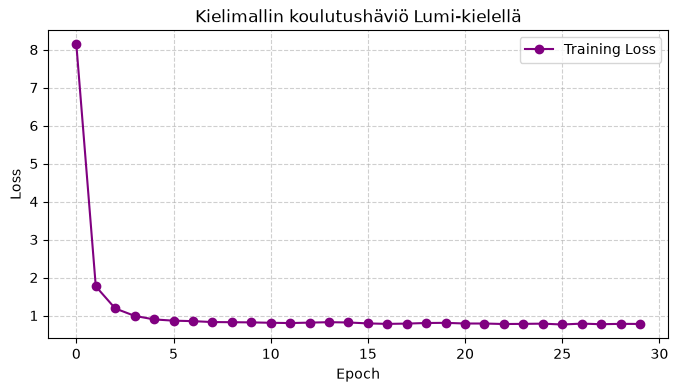

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(loss_historia, marker='o', color='purple', label='Training Loss')
plt.title('Kielimallin koulutushäviö Lumi-kielellä')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## Vaihe 5: Interaktiivinen Prompter ja Tekstinsukupolvi

Kirjoitetaan funktio, jolla voimme antaa mallille syötteen (esim. `<bos> kissa`) ja pyytää sitä jatkamaan sitä sana kerrallaan (autoregressiivisesti).

Käytämme lämpötilasamplingiä (**Temperature Scaling**):
- Korkea lämpötila ($T > 1.0$) tekee teksteistä luovempia ja yllättävämpiä (mutta alttiimpia virheille).
- Matala lämpötila ($T \to 0$) tekee mallista täysin deterministisen, jolloin se valitsee aina vain todennäköisimmän sanan (Greedy Search).

Tulostamme myös jokaisella askeleella sen hetkisen todennäköisyysjakauman, jotta näemme tarkalleen mitä malli miettii!


In [25]:
def generoi_tekstiä(malli, alkuprompt, max_new_tokens=10, temperature=1.0):
    malli.eval()
    # Koodataan aloitusteksti
    input_ids = tokenizer.encode(alkuprompt)
    current_ids = list(input_ids)
    
    print(f"Alkuperäinen prompti: '{alkuprompt}'")
    print("Ennustusvaiheet:")
    print("-" * 50)
    
    for step in range(max_new_tokens):
        # Muutetaan tensoriksi ja lisätään batch-ulottuvuus
        input_tensor = torch.tensor([current_ids]).to(device)
        
        with torch.no_grad():
            logits = malli(input_tensor) # (1, seq_len, vocab_size)
            
        # Otetaan vain viimeisen sanan ennuste (logits)
        next_token_logits = logits[0, -1, :] / (temperature + 1e-8)
        
        # Lasketaan todennäköisyydet Softmaxilla
        probs = torch.softmax(next_token_logits, dim=-1)
        
        # Näytetään 3 todennäköisintä seuraavaa sanaa tällä askeleella
        top_val, top_idx = torch.topk(probs, k=3)
        top_words = [f"{tokenizer.id2word[idx.item()]}: {val.item()*100:.1f}%" for val, idx in zip(top_val, top_idx)]
        print(f"Sanan {step+1:02d} ennuste. Nykyinen lause: '... {tokenizer.decode(current_ids[-2:])}' | Ehdokkaat: {', '.join(top_words)}")
        
        # Valitaan seuraava sana jakaumasta
        next_token_id = torch.multinomial(probs, num_samples=1).item()
        
        current_ids.append(next_token_id)
        
        # Jos saavutetaan lauseen loppu, lopetetaan generointi
        if next_token_id == tokenizer.word2id['<eos>']:
            break
            
    print("-" * 50)
    generoitu_teksti = tokenizer.decode(current_ids)
    print(f"Lopullinen tulos:  {generoitu_teksti}\n")
    return generoitu_teksti

# Kokeillaan generointia muutamalla eri promptilla
generoi_tekstiä(model, "<bos> kissa jahtaa", max_new_tokens=8, temperature=0.7)
generoi_tekstiä(model, "<bos> koira syö", max_new_tokens=8, temperature=0.5)
generoi_tekstiä(model, "<bos> hiiri nukkuu", max_new_tokens=8, temperature=0.1) # Determininen matala lämpötila


Alkuperäinen prompti: '<bos> kissa jahtaa'
Ennustusvaiheet:
--------------------------------------------------
Sanan 01 ennuste. Nykyinen lause: '... kissa jahtaa' | Ehdokkaat: hiiri: 85.6%, koira: 14.1%, kissa: 0.2%
Sanan 02 ennuste. Nykyinen lause: '... jahtaa hiiri' | Ehdokkaat: ja: 100.0%, syö: 0.0%, katsoo: 0.0%
Sanan 03 ennuste. Nykyinen lause: '... hiiri ja' | Ehdokkaat: kissa: 47.9%, hiiri: 34.2%, koira: 18.0%
Sanan 04 ennuste. Nykyinen lause: '... ja hiiri' | Ehdokkaat: katsoo: 33.5%, syö: 27.5%, jahtaa: 23.8%
Sanan 05 ennuste. Nykyinen lause: '... hiiri syö' | Ehdokkaat: juusto: 77.8%, kala: 22.1%, koira: 0.0%
Sanan 06 ennuste. Nykyinen lause: '... syö juusto' | Ehdokkaat: <eos>: 100.0%, katsoo: 0.0%, hyvin: 0.0%
--------------------------------------------------
Lopullinen tulos:  <bos> kissa jahtaa hiiri ja hiiri syö juusto <eos>

Alkuperäinen prompti: '<bos> koira syö'
Ennustusvaiheet:
--------------------------------------------------
Sanan 01 ennuste. Nykyinen lause: '..

'<bos> hiiri nukkuu koira ja kissa jahtaa hiiri <eos>'

## Vaihe 6: Huomiokartan (Attention Map) visualisointi

Yksi Transformer-malleja helpoiten selittävistä työkaluista on **Attention Map** (huomiomatriisi). Koska mallimme on pieni, voimme helposti piirtää kuvaajan siitä, miten kumpikin attention-pää kohdisti huomionsa lausetta käsiteltäessä.

Otetaan esimerkkilause, ajetaan se mallin läpi ja visualisoidaan molempien päiden huomiopainot ensimmäisestä Transformer-lohkosta.


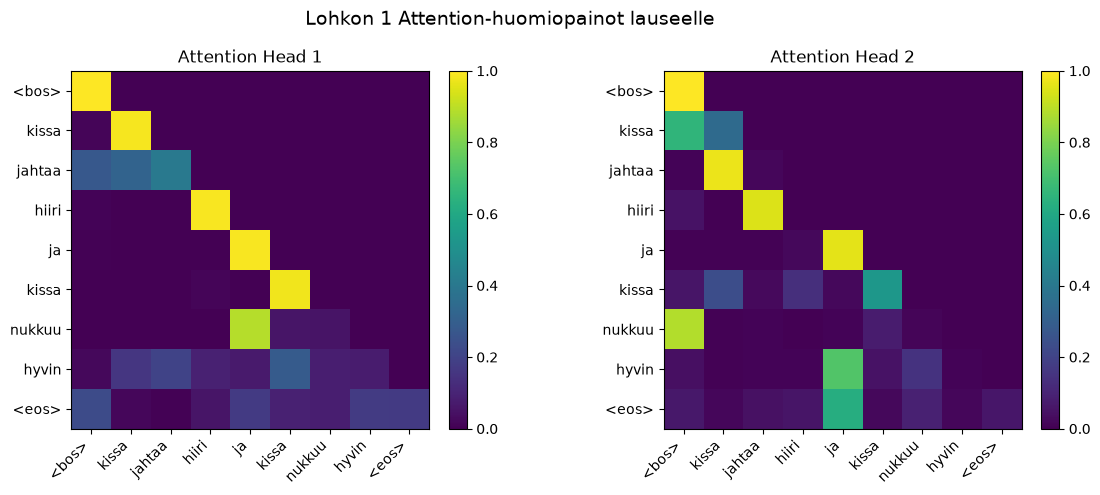

In [26]:
def visualisoi_huomio(malli, lause, kerros_idx=0):
    malli.eval()
    input_ids = tokenizer.encode(lause)
    words = [tokenizer.id2word[idx] for idx in input_ids]
    
    input_tensor = torch.tensor([input_ids]).to(device)
    
    with torch.no_grad():
        _ = malli(input_tensor)
        
    # Haetaan tallennetut huomiopainot halutusta lohkosta
    # Huomiopainojen muoto: (1, n_heads, seq_len, seq_len)
    attn_weights = malli.blocks[kerros_idx].attn.attention_weights[0].cpu().numpy()
    
    n_heads = attn_weights.shape[0]
    seq_len = len(words)
    
    fig, axes = plt.subplots(1, n_heads, figsize=(12, 5))
    
    for head in range(n_heads):
        ax = axes[head] if n_heads > 1 else axes
        # Piirretään lämpökartta (poistetaan yläkolmio maskauksen vuoksi visualisoinnin selkeyttämiseksi)
        im = ax.imshow(attn_weights[head, :seq_len, :seq_len], cmap='viridis', vmin=0, vmax=1)
        
        ax.set_xticks(np.arange(seq_len))
        ax.set_yticks(np.arange(seq_len))
        ax.set_xticklabels(words, rotation=45, ha="right")
        ax.set_yticklabels(words)
        
        ax.set_title(f"Attention Head {head+1}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
    plt.suptitle(f"Lohkon {kerros_idx+1} Attention-huomiopainot lauseelle", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

# Kokeillaan visualisointia lauseelle
visualisoi_huomio(model, "<bos> kissa jahtaa hiiri ja kissa nukkuu hyvin <eos>")


## Vaihe 7: Kokeile itse ja tee tweekkejä!

Tässä on muutamia ideoita, joilla voit leikkiä ja testata, miten mallin toiminta muuttuu:
1. **Muuta verkon kokoa**: Mitä tapahtuu, jos kasvatat tai pienennät embedding-kokoa (`d_model`) tai kerrosten määrää (`n_layers`)?
2. **Muuta lämpötilaa**: Testaa arvoja väliltä `0.01` (täysin ennustettava) ja `2.0` (sekava ja satunnainen).
3. **Lisää uusia sanoja lelukieleen**: Voit lisätä `LumiTokenizer`-luokkaan uusia sanoja kuten `pupu` tai `juoksee` ja luoda aineistogeneraattoriin uusia sääntöjä. Muista kouluttaa malli uudestaan muutoksen jälkeen!
4. **Kokeile ilman maskausta**: Mitä tapahtuisi, jos poistaisimme kausaalisen maskin ($M$) attention-kerroksesta? Malli pystyisi "luntata" seuraavan sanan suoraan syötteestä, jolloin koulutushäviö menisi heti nollaan, mutta tekstin generointi ei enää onnistuisi autoregressiivisesti.
